In [19]:
import pandas as pd
import numpy as np

## Analysis of Game 21500390 - High Threat in Defensive Zone Using QUT Methodology

Running the QUT machinery on our multi game data typically showed consistent results. Higher propensity to the right of the basket, occasional perimeter threat increase and lower propensity in the defensize zone and in the center of the offensize zone. Game 21500390 however, had the expected signal mentioned above and high threat in the defensive zone. The output is below.

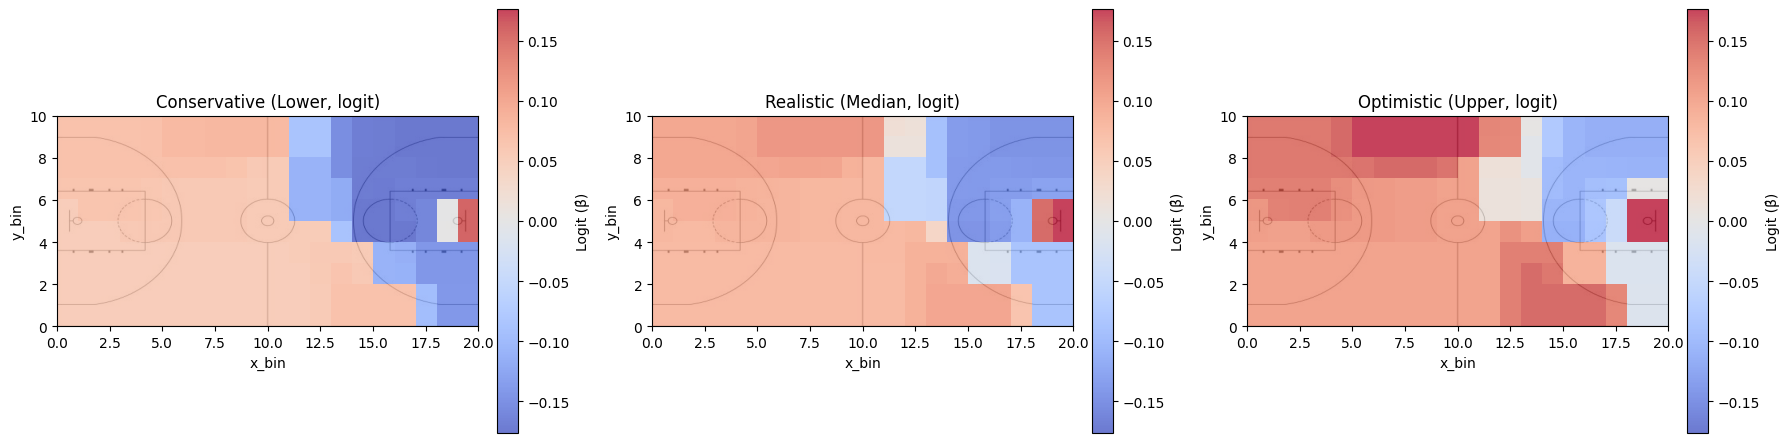

Because of this anomaly, we have decided to dig a little deeper on this topic. The assumption we are making is that good defense leading directly into succesful scoring increased the threat propensity in the defensive zone. We will be looking at all possessions with defensive actions such as blocks, defensive rebounds, steals and turnovers to see if they had an effect on the outcome. We will be looking at the play-by-play data to start, then adding in movement data from the mentioned game to construct profiles that are using movements from defensive possesions to replicate this outcome. We will also extend this to other games by selecting their defensive plays and constructing a aggregated "defense forward" profile.

In [20]:
df = pd.read_csv("nbastats_2015.csv")
df.head()

,GAME_ID,EVENTNUM,EVENTMSGTYPE,EVENTMSGACTIONTYPE,PERIOD,WCTIMESTRING,PCTIMESTRING,HOMEDESCRIPTION,NEUTRALDESCRIPTION,VISITORDESCRIPTION,...,PLAYER2_TEAM_NICKNAME,PLAYER2_TEAM_ABBREVIATION,PERSON3TYPE,PLAYER3_ID,PLAYER3_NAME,PLAYER3_TEAM_ID,PLAYER3_TEAM_CITY,PLAYER3_TEAM_NICKNAME,PLAYER3_TEAM_ABBREVIATION,VIDEO_AVAILABLE_FLAG
0,21500001,0,12,0,1,8:12 PM,720,NaN,Start of 1st Period (8:12 PM EST),NaN,...,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,0
1,21500001,1,10,0,1,8:12 PM,720,Jump Ball Horford vs. Drummond: Tip to Ilyasova,NaN,NaN,...,Pistons,DET,5,101141,Ersan Ilyasova,1.610613e+09,Detroit,Pistons,DET,1
2,21500001,2,2,42,1,8:13 PM,439,Horford BLOCK (1 BLK),NaN,MISS Drummond 2' Driving Layup,...,NaN,NaN,4,201143,Al Horford,1.610613e+09,Atlanta,Hawks,ATL,1
3,21500001,3,4,0,1,8:13 PM,561,Bazemore REBOUND (Off:0 Def:1),NaN,NaN,...,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,1
4,21500001,4,5,45,1,8:13 PM,683,Bazemore Out of Bounds - Bad Pass Turnover Tur...,NaN,NaN,...,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,1


In [21]:
df_21500390 = df[df["GAME_ID"] == 21500390]
df_21500390

,GAME_ID,EVENTNUM,EVENTMSGTYPE,EVENTMSGACTIONTYPE,PERIOD,WCTIMESTRING,PCTIMESTRING,HOMEDESCRIPTION,NEUTRALDESCRIPTION,VISITORDESCRIPTION,...,PLAYER2_TEAM_NICKNAME,PLAYER2_TEAM_ABBREVIATION,PERSON3TYPE,PLAYER3_ID,PLAYER3_NAME,PLAYER3_TEAM_ID,PLAYER3_TEAM_CITY,PLAYER3_TEAM_NICKNAME,PLAYER3_TEAM_ABBREVIATION,VIDEO_AVAILABLE_FLAG
255371,21500390,0,12,0,1,8:12 PM,720,NaN,Start of 1st Period (8:12 PM EST),NaN,...,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,0
255372,21500390,1,10,0,1,8:12 PM,720,Jump Ball Whiteside vs. Biyombo: Tip to Bosh,NaN,NaN,...,Raptors,TOR,4,2547,Chris Bosh,1.610613e+09,Miami,Heat,MIA,1
255373,21500390,2,5,1,1,8:13 PM,744,Dragic Bad Pass Turnover (P1.T1),NaN,Johnson STEAL (1 STL),...,Raptors,TOR,0,0,NaN,NaN,NaN,NaN,NaN,1
255374,21500390,3,1,5,1,8:13 PM,927,NaN,NaN,Scola 2' Layup (2 PTS) (Johnson 1 AST),...,Raptors,TOR,0,0,NaN,NaN,NaN,NaN,NaN,1
255375,21500390,4,6,2,1,8:13 PM,927,Dragic S.FOUL (P1.T1) (L.Wood),NaN,NaN,...,Raptors,TOR,1,0,NaN,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255763,21500390,475,9,2,4,10:16 PM,170055,NaN,NaN,Raptors Timeout: Short (Reg.3 Short 1),...,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,0
255764,21500390,479,1,42,4,10:18 PM,170848,NaN,NaN,Lowry 2' Driving Layup (21 PTS),...,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,1
255765,21500390,480,2,1,4,10:18 PM,171519,MISS Bosh 3PT Jump Shot,NaN,NaN,...,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,1
255766,21500390,481,4,0,4,10:18 PM,171580,NaN,NaN,DeRozan REBOUND (Off:0 Def:4),...,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,1


In [22]:
df_21500390[["HOMEDESCRIPTION", "VISITORDESCRIPTION", "PERIOD"]].head(50)

,HOMEDESCRIPTION,VISITORDESCRIPTION,PERIOD
255371,NaN,NaN,1
255372,Jump Ball Whiteside vs. Biyombo: Tip to Bosh,NaN,1
255373,Dragic Bad Pass Turnover (P1.T1),Johnson STEAL (1 STL),1
255374,NaN,Scola 2' Layup (2 PTS) (Johnson 1 AST),1
255375,Dragic S.FOUL (P1.T1) (L.Wood),NaN,1
255376,NaN,Scola Free Throw 1 of 1 (3 PTS),1
255377,MISS Whiteside 9' Turnaround Hook Shot,NaN,1
255378,NaN,DeRozan REBOUND (Off:0 Def:1),1
255379,NaN,Scola 2' Driving Layup (5 PTS),1
255380,Bosh 24' 3PT Jump Shot (3 PTS) (Wade 1 AST),NaN,1


In [23]:
# Count home possession losses that the visitors convert on their resulting possession.
game = (
    df_21500390.sort_values(["PERIOD", "EVENTNUM"])
    .reset_index(drop=True)
    .copy()
)
game["EVENTMSGTYPE"] = pd.to_numeric(game["EVENTMSGTYPE"], errors="coerce")
home_desc = game["HOMEDESCRIPTION"].fillna("").astype(str)
visitor_desc = game["VISITORDESCRIPTION"].fillna("").astype(str)


def previous_missed_shot(row_number):
    """Return the prior missed-shot row, ignoring administrative events."""
    for prior in range(row_number - 1, -1, -1):
        event_type = game.at[prior, "EVENTMSGTYPE"]
        if event_type in (2, 3):
            descriptions = f"{home_desc.iat[prior]} {visitor_desc.iat[prior]}"
            if "MISS" in descriptions.upper():
                return prior
        if event_type in (1, 4, 5, 12, 13):
            break
    return None


possession_losses = []
for row_number, row in game.iterrows():
    event_type = row["EVENTMSGTYPE"]

    # A recorded home turnover, including a turnover caused by a visitor steal.
    if event_type == 5 and "TURNOVER" in home_desc.iat[row_number].upper():
        causes = ["turnover"]
        if "STEAL" in visitor_desc.iat[row_number].upper():
            causes.append("steal")
        possession_losses.append(
            {
                "start_row": row_number,
                "PERIOD": row["PERIOD"],
                "PCTIMESTRING": row["PCTIMESTRING"],
                "LOSS_EVENTNUM": row["EVENTNUM"],
                "HOME_EVENT": home_desc.iat[row_number],
                "VISITOR_TAKEAWAY": visitor_desc.iat[row_number],
                "CAUSE": " + ".join(causes),
            }
        )

    # A visitor rebound is defensive only when it follows a missed home shot.
    elif event_type == 4 and visitor_desc.iat[row_number]:
        shot_row = previous_missed_shot(row_number)
        if shot_row is not None and home_desc.iat[shot_row].upper().startswith("MISS"):
            causes = ["defensive rebound"]
            if "BLOCK" in visitor_desc.iat[shot_row].upper():
                causes.append("block")
            possession_losses.append(
                {
                    "start_row": row_number,
                    "PERIOD": row["PERIOD"],
                    "PCTIMESTRING": row["PCTIMESTRING"],
                    "LOSS_EVENTNUM": row["EVENTNUM"],
                    "HOME_EVENT": home_desc.iat[shot_row],
                    "VISITOR_TAKEAWAY": visitor_desc.iat[row_number],
                    "CAUSE": " + ".join(causes),
                }
            )


def resulting_visitor_score(start_row):
    """Find a visitor score before that visitor possession ends."""
    for row_number in range(start_row + 1, len(game)):
        event_type = game.at[row_number, "EVENTMSGTYPE"]
        home_event = home_desc.iat[row_number]
        visitor_event = visitor_desc.iat[row_number]

        if event_type == 13:  # End of period
            return None
        if visitor_event and event_type == 1:
            return row_number, visitor_event
        if visitor_event and event_type == 3:
            # Combine all visitor free throws taken at this clock stoppage.
            free_throw_rows = []
            for free_throw_row in range(row_number, len(game)):
                same_period = game.at[free_throw_row, "PERIOD"] == game.at[row_number, "PERIOD"]
                same_clock = game.at[free_throw_row, "PCTIMESTRING"] == game.at[row_number, "PCTIMESTRING"]
                if not (same_period and same_clock):
                    break
                free_throw_event = visitor_desc.iat[free_throw_row]
                if game.at[free_throw_row, "EVENTMSGTYPE"] == 3 and free_throw_event:
                    free_throw_rows.append(free_throw_row)

            made_free_throws = [
                free_throw_row
                for free_throw_row in free_throw_rows
                if "MISS" not in visitor_desc.iat[free_throw_row].upper()
            ]
            if made_free_throws:
                combined_description = " | ".join(
                    visitor_desc.iat[free_throw_row] for free_throw_row in free_throw_rows
                )
                return made_free_throws[0], combined_description
        if event_type == 5 and visitor_event:  # Visitor turnover
            return None
        if event_type == 4 and home_event:  # Home rebound of a visitor miss
            return None
        if event_type in (1, 5) and home_event:  # Home already regained possession
            return None
    return None


converted_losses = []
for loss in possession_losses:
    score = resulting_visitor_score(loss["start_row"])
    if score is not None:
        score_row, score_description = score
        converted_losses.append(
            {
                key: value for key, value in loss.items() if key != "start_row"
            }
            | {
                "SCORE_EVENTNUM": game.at[score_row, "EVENTNUM"],
                "VISITOR_SCORE": score_description,
            }
        )

converted_home_possession_losses = pd.DataFrame(converted_losses)
cause_summary = pd.Series(
    {
        "Defensive rebounds": converted_home_possession_losses["CAUSE"].str.contains("defensive rebound").sum(),
        "Blocks (subset of defensive rebounds)": converted_home_possession_losses["CAUSE"].str.contains("block").sum(),
        "Steals": converted_home_possession_losses["CAUSE"].str.contains("steal").sum(),
        "Other recorded turnovers": (converted_home_possession_losses["CAUSE"] == "turnover").sum(),
    },
    name="COUNT",
)
print(
    "Home possession losses that led directly to a visitor score:",
    len(converted_home_possession_losses),
)
display(cause_summary.to_frame())
converted_home_possession_losses

Home possession losses that led directly to a visitor score: 29


,COUNT
Defensive rebounds,20
Blocks (subset of defensive rebounds),3
Steals,9
Other recorded turnovers,0


,PERIOD,PCTIMESTRING,LOSS_EVENTNUM,HOME_EVENT,VISITOR_TAKEAWAY,CAUSE,SCORE_EVENTNUM,VISITOR_SCORE
0,1,744,2,Dragic Bad Pass Turnover (P1.T1),Johnson STEAL (1 STL),turnover + steal,3,Scola 2' Layup (2 PTS) (Johnson 1 AST)
1,1,2452,8,MISS Whiteside 9' Turnaround Hook Shot,DeRozan REBOUND (Off:0 Def:1),defensive rebound,9,Scola 2' Driving Layup (5 PTS)
2,1,8613,15,Wade Lost Ball Turnover (P1.T2),DeRozan STEAL (1 STL),turnover + steal,16,Scola 4' Hook Shot (9 PTS) (DeRozan 1 AST)
3,1,11724,23,Wade Lost Ball Turnover (P2.T3),Lowry STEAL (1 STL),turnover + steal,26,DeRozan 6' Driving Floating Jump Shot (2 PTS)
4,1,23741,59,Wade Lost Ball Turnover (P4.T5),Ross STEAL (1 STL),turnover + steal,61,DeRozan 15' Jump Shot (4 PTS)
5,1,28865,70,MISS Dragic 4' Jump Shot,Ross REBOUND (Off:0 Def:1),defensive rebound + block,80,DeRozan Free Throw 1 of 2 (5 PTS) | DeRozan Fr...
6,1,37832,99,MISS Deng 2' Driving Finger Roll Layup,Patterson REBOUND (Off:0 Def:2),defensive rebound,103,DeRozan Free Throw 1 of 2 (7 PTS) | DeRozan Fr...
7,2,44432,131,Bosh Bad Pass Turnover (P1.T6),Joseph STEAL (1 STL),turnover + steal,132,Lowry 1' Layup (4 PTS) (Joseph 1 AST)
8,2,47726,138,MISS Udrih 18' Jump Shot,Patterson REBOUND (Off:0 Def:3),defensive rebound,139,Johnson 2' Driving Finger Roll Layup (2 PTS)
9,2,52850,148,MISS Dragic 25' 3PT Jump Shot,Lowry REBOUND (Off:0 Def:1),defensive rebound,149,Ross 24' 3PT Jump Shot (6 PTS) (Patterson 1 AST)


In [24]:
# Build corrected Raptors possessions and identify defense-forward starts.
from pathlib import Path

GAME_ID = 21500390
TRACKING_GAME_ID = f"{GAME_ID:010d}"
RAPTORS_TEAM_ID = 1610612761

possession_path = Path("multi_game_data") / "0021500390_possessions.csv"
movement_path = Path("multi_game_data") / "multi_game_data.csv"

game_possessions = pd.read_csv(possession_path)
game_possessions["offense_team_id"] = pd.to_numeric(
    game_possessions["offense_team_id"], errors="coerce"
).astype("Int64")
game_possessions["period"] = pd.to_numeric(
    game_possessions["period"], errors="coerce"
).astype("Int64")
game_possessions["possession_end_elapsed"] = pd.to_numeric(
    game_possessions["possession_end_elapsed"], errors="coerce"
)
game_possessions["points_scored"] = pd.to_numeric(
    game_possessions["points_scored"], errors="coerce"
).fillna(0).astype(int)
game_possessions["event_count"] = pd.to_numeric(
    game_possessions["event_count"], errors="coerce"
).fillna(0).astype(int)
game_possessions["_source_row"] = np.arange(len(game_possessions))
game_possessions["possession_start_elapsed_raw"] = game_possessions["possession_start_elapsed"]
game_possessions["possession_start_elapsed"] = game_possessions["possession_end_elapsed"].shift(
    fill_value=0
)
same_team = game_possessions["offense_team_id"].eq(
    game_possessions["offense_team_id"].shift()
)
same_period = game_possessions["period"].eq(game_possessions["period"].shift())
same_end_time = game_possessions["possession_end_elapsed"].eq(
    game_possessions["possession_end_elapsed"].shift()
)
game_possessions["is_clock_stopped_continuation"] = (
    same_team & same_period & same_end_time
)

raptors_segment_mask = game_possessions["offense_team_id"] == RAPTORS_TEAM_ID
raptors_possession_segments = game_possessions.loc[raptors_segment_mask].copy()
raptors_possession_segments["SOURCE_POSSESSION_NUMBER"] = np.arange(
    1, len(raptors_possession_segments) + 1
)
raptors_possession_segments["RAPTORS_POSSESSION_NUMBER"] = (
    ~raptors_possession_segments["is_clock_stopped_continuation"]
).cumsum().astype(int)

# Aggregate clock-stopped continuation rows (the remaining Toronto case is an and-one FT).
raptors_possessions = (
    raptors_possession_segments.groupby("RAPTORS_POSSESSION_NUMBER", as_index=False)
    .agg(
        period=("period", "first"),
        possession_start_elapsed=("possession_start_elapsed", "first"),
        possession_end_elapsed=("possession_end_elapsed", "last"),
        offense_team_id=("offense_team_id", "first"),
        points_scored=("points_scored", "sum"),
        event_count=("event_count", "sum"),
        source_possession_numbers=(
            "SOURCE_POSSESSION_NUMBER",
            lambda values: tuple(int(value) for value in values),
        ),
        contains_clock_stopped_continuation=(
            "is_clock_stopped_continuation", "any"
        ),
    )
)
raptors_possessions["possession_duration"] = (
    raptors_possessions["possession_end_elapsed"]
    - raptors_possessions["possession_start_elapsed"]
)


# possession_losses from the prior cell contains Miami turnovers and Raptors defensive rebounds.
defense_forward_records = []
last_matched_source_row = -1
for loss in sorted(possession_losses, key=lambda item: item["LOSS_EVENTNUM"]):
    loss_event = game.loc[game["EVENTNUM"] == loss["LOSS_EVENTNUM"]].iloc[0]
    event_elapsed = float(loss_event["PCTIMESTRING"]) / 60.0
    candidates = raptors_possession_segments.loc[
        (raptors_possession_segments["period"] == int(loss_event["PERIOD"]))
        & (raptors_possession_segments["_source_row"] > last_matched_source_row)
    ]
    if candidates.empty:
        # A defensive rebound at the final horn has no ensuing Raptors possession.
        continue

    offsets = (candidates["possession_start_elapsed"] - event_elapsed).abs()
    matched_segment = candidates.loc[offsets.idxmin()]
    last_matched_source_row = int(matched_segment["_source_row"])
    defense_forward_records.append(
        {
            "LOSS_EVENTNUM": int(loss["LOSS_EVENTNUM"]),
            "PERIOD": int(loss_event["PERIOD"]),
            "CAUSE": loss["CAUSE"],
            "DEFENSIVE_START_TYPE": (
                "opponent turnover"
                if "turnover" in loss["CAUSE"]
                else "defensive rebound"
            ),
            "RAPTORS_POSSESSION_NUMBER": int(
                matched_segment["RAPTORS_POSSESSION_NUMBER"]
            ),
            "SOURCE_POSSESSION_NUMBER": int(
                matched_segment["SOURCE_POSSESSION_NUMBER"]
            ),
            "POSSESSION_LINK_OFFSET_SECONDS": float(offsets.min()),
        }
    )

defense_forward_possession_details = pd.DataFrame(defense_forward_records)
if defense_forward_possession_details["POSSESSION_LINK_OFFSET_SECONDS"].max() > 15:
    raise ValueError("A defensive event-to-possession match is more than 15 seconds away.")
if defense_forward_possession_details["RAPTORS_POSSESSION_NUMBER"].duplicated().any():
    raise ValueError("Multiple defensive starts were matched to one Raptors possession.")

defense_forward_possession_numbers = sorted(
    defense_forward_possession_details["RAPTORS_POSSESSION_NUMBER"].unique()
)
raptors_defense_forward_possessions = raptors_possessions.loc[
    raptors_possessions["RAPTORS_POSSESSION_NUMBER"].isin(
        defense_forward_possession_numbers
    )
].copy()
raptors_scoring_defense_forward_possessions = raptors_defense_forward_possessions.loc[
    raptors_defense_forward_possessions["points_scored"] > 0
].copy()
points_scored_through_defense = int(
    raptors_defense_forward_possessions["points_scored"].sum()
)
defense_forward_possession_details = defense_forward_possession_details.merge(
    raptors_defense_forward_possessions[
        ["RAPTORS_POSSESSION_NUMBER", "points_scored"]
    ].rename(columns={"points_scored": "POINTS_SCORED"}),
    on="RAPTORS_POSSESSION_NUMBER",
    how="left",
)

movement_data = pd.read_csv(movement_path, low_memory=False)
movement_data = movement_data.loc[:, ~movement_data.columns.str.startswith("Unnamed:")].copy()
movement_game_ids = (
    movement_data["game_id"].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(10)
)
raptors_movement_data = movement_data.loc[movement_game_ids == TRACKING_GAME_ID].copy()
raptors_movement_data["SOURCE_POSSESSION_NUMBER"] = pd.to_numeric(
    raptors_movement_data["possession_number"], errors="coerce"
).astype("Int64")
source_to_corrected_possession = raptors_possession_segments[
    ["SOURCE_POSSESSION_NUMBER", "RAPTORS_POSSESSION_NUMBER"]
].drop_duplicates()
raptors_movement_data = raptors_movement_data.merge(
    source_to_corrected_possession,
    on="SOURCE_POSSESSION_NUMBER",
    how="left",
    validate="many_to_one",
)
if raptors_movement_data["SOURCE_POSSESSION_NUMBER"].nunique() != len(raptors_possession_segments):
    raise ValueError("Movement data does not contain every Raptors source segment.")
if raptors_movement_data["RAPTORS_POSSESSION_NUMBER"].nunique() != len(raptors_possessions):
    raise ValueError("Corrected possession and movement counts do not match.")

raptors_defense_forward_movement_data = raptors_movement_data.loc[
    raptors_movement_data["RAPTORS_POSSESSION_NUMBER"].isin(
        defense_forward_possession_numbers
    )
].copy()
raptors_scoring_defense_forward_movement_data = raptors_movement_data.loc[
    raptors_movement_data["RAPTORS_POSSESSION_NUMBER"].isin(
        raptors_scoring_defense_forward_possessions["RAPTORS_POSSESSION_NUMBER"]
    )
].copy()

# Aliases using the project's broader meaning of a turnover (turnover or defensive rebound).
raptors_possessions_after_turnovers = raptors_defense_forward_possessions
raptors_movement_after_turnovers = raptors_defense_forward_movement_data
raptors_clock_stopped_continuations = raptors_possession_segments.loc[
    raptors_possession_segments["is_clock_stopped_continuation"]
].copy()

raptors_possession_summary = pd.Series(
    {
        "Raw Raptors possession segments": len(raptors_possession_segments),
        "Clock-stopped continuation segments merged": len(raptors_clock_stopped_continuations),
        "Total corrected Raptors possessions": len(raptors_possessions),
        "Beginning after opponent turnovers": (
            defense_forward_possession_details["DEFENSIVE_START_TYPE"]
            .eq("opponent turnover")
            .sum()
        ),
        "Beginning after defensive rebounds": (
            defense_forward_possession_details["DEFENSIVE_START_TYPE"]
            .eq("defensive rebound")
            .sum()
        ),
        "Total defense-forward possessions": len(raptors_defense_forward_possessions),
        "Defense-forward possessions where Toronto scored": len(raptors_scoring_defense_forward_possessions),
        "Points scored through defense-forward possessions": points_scored_through_defense,
    },
    name="COUNT",
)

display(raptors_possession_summary.to_frame())
print("All Raptors possessions:")
display(raptors_possessions)
print(
    "Defense-forward Raptors possession numbers:",
    defense_forward_possession_numbers,
)
defense_forward_possession_details


,COUNT
Raw Raptors possession segments,89
Clock-stopped continuation segments merged,1
Total corrected Raptors possessions,88
Beginning after opponent turnovers,13
Beginning after defensive rebounds,32
Total defense-forward possessions,45
Defense-forward possessions where Toronto scored,29
Points scored through defense-forward possessions,62


All Raptors possessions:


,RAPTORS_POSSESSION_NUMBER,period,possession_start_elapsed,possession_end_elapsed,offense_team_id,points_scored,event_count,source_possession_numbers,contains_clock_stopped_continuation,possession_duration
0,1,1,24,27,1610612761,3,3,"(1, 2)",True,3
1,2,1,52,69,1610612761,2,1,"(3,)",False,17
2,3,1,84,103,1610612761,0,2,"(4,)",False,19
3,4,1,114,132,1610612761,2,1,"(5,)",False,18
4,5,1,153,159,1610612761,2,1,"(6,)",False,6
...,...,...,...,...,...,...,...,...,...,...
83,84,4,2709,2735,1610612761,2,1,"(85,)",False,26
84,85,4,2746,2765,1610612761,2,1,"(86,)",False,19
85,86,4,2773,2809,1610612761,0,5,"(87,)",False,36
86,87,4,2817,2823,1610612761,2,3,"(88,)",False,6


Defense-forward Raptors possession numbers: [np.int64(1), np.int64(2), np.int64(5), np.int64(7), np.int64(8), np.int64(13), np.int64(14), np.int64(17), np.int64(18), np.int64(21), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(29), np.int64(31), np.int64(37), np.int64(41), np.int64(43), np.int64(44), np.int64(46), np.int64(52), np.int64(53), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(64), np.int64(65), np.int64(69), np.int64(70), np.int64(71), np.int64(72), np.int64(74), np.int64(76), np.int64(79), np.int64(80), np.int64(81), np.int64(83), np.int64(84), np.int64(86), np.int64(87), np.int64(88)]


,LOSS_EVENTNUM,PERIOD,CAUSE,DEFENSIVE_START_TYPE,RAPTORS_POSSESSION_NUMBER,SOURCE_POSSESSION_NUMBER,POSSESSION_LINK_OFFSET_SECONDS,POINTS_SCORED
0,2,1,turnover + steal,opponent turnover,1,1,11.600000,3
1,8,1,defensive rebound,defensive rebound,2,3,11.133333,2
2,15,1,turnover + steal,opponent turnover,5,6,9.450000,2
3,23,1,turnover + steal,opponent turnover,7,8,8.600000,2
4,28,1,defensive rebound,defensive rebound,8,9,7.983333,0
5,55,1,turnover + steal,opponent turnover,13,14,5.600000,0
6,59,1,turnover + steal,opponent turnover,14,15,5.316667,2
7,70,1,defensive rebound + block,defensive rebound,17,18,3.916667,2
8,85,1,defensive rebound,defensive rebound,18,19,3.466667,0
9,99,1,defensive rebound,defensive rebound,21,22,1.466667,2
